# Неделя 4. Вторник
## Обучение без учителя
### Кластеризация текстов

✏️  Сегодняшним вашим заданием будет кластеразиция текстов. 

* У нас имеется выборка из 5000 сообщений из новостных телеграм каналов на разные тематики
* Необходимо предобработать данные, выделить кластеры
* Собирать будем такой папйлайн `предварительный препроцессинг` __->__ `удаление стоп-слов` __->__ `лемматизация` __->__ `векторизация текста` __->__ `понижение размерности` __->__ `кластеризация`

__1.__ Подгрузите датасет `aux/tg_channels.csv`

In [17]:
import pandas as pd

df = pd.read_csv("tg_channels.csv") 

In [18]:
df.head()

,content,label
0,Мужчину в метро оскорбила сумка с репродукцией...,искусство
1,В одном из кинотеатров Нидерландов перед просм...,маркетинг
2,🖼️ «Христос в Галилейском море» — Эжен Делакру...,искусство
3,"24 года Яндекс работает, чтобы делать жизнь уд...",технологии
4,Телеком 2022 - 2 прибыльных #MVNO и остальные🔥...,технологии


In [ ]:
texts = df["content"].copy()
texts.head()

,content,label
0,Мужчину в метро оскорбила сумка с репродукцией...,искусство
1,В одном из кинотеатров Нидерландов перед просм...,маркетинг
2,🖼️ «Христос в Галилейском море» — Эжен Делакру...,искусство
3,"24 года Яндекс работает, чтобы делать жизнь уд...",технологии
4,Телеком 2022 - 2 прибыльных #MVNO и остальные🔥...,технологии


__2.__ Сделай необходимую предобработку текста `aux/tg_channels.csv`. Всю ее оберните в функцию `clean`

   * Немножко полистайте свои тексты, посмотрите проблемы, которые есть в них
   * Удалите ненужные сущности, например ссылки, смайлы, и т.д. Все, что считаете мусором и не нужным для кластеризации и только будет создавать лишние токены
  
💡 __совет__:
* Не пытайтесь сделать сразу идеальную отчистку, в разных текстах, разные проблемы, лучше сделать baseline-проходку, а дальше вернуться, уже видя проблемы и чдочищать их
* Можно сразу результат прикреплять в `DataFrame`, например создать колонку `cleaned_text`

In [20]:
import re
from cleantext import clean

# паттерны для "расшивки"
CASE_GLUE     = re.compile(r"(?<=[a-zа-яё])(?=[A-ZА-ЯЁ])")   # буква→Прописная
DIGIT_LETTER  = re.compile(r"(?<=[0-9])(?=[A-Za-zА-Яа-яЁё])") # цифра→буква
LETTER_DIGIT  = re.compile(r"(?<=[A-Za-zА-Яа-яЁё])(?=[0-9])") # буква→цифра
PUNCT_FOLLOW  = re.compile(r"([.,;:!?…])(?=\S)")              # знак→сразу слово

NON_LETTER = re.compile(r"[^0-9a-zA-Zа-яА-ЯёЁ]+")

def universal_clean(x: str) -> str:
    if not isinstance(x, str):
        return ""
    # --- расшивка ---
    x = CASE_GLUE.sub(" ", x)
    x = DIGIT_LETTER.sub(" ", x)
    x = LETTER_DIGIT.sub(" ", x)
    x = PUNCT_FOLLOW.sub(r"\1 ", x)

    # --- заменяем всё лишнее на пробел ---
    x = NON_LETTER.sub(" ", x)

    # --- clean-text: только ссылки/почта/телефоны/валюта ---
    x = clean(
        x,
        lower=True,
        to_ascii=False,  # оставляем кириллицу
        no_urls=True,
        no_emails=True,
        no_phone_numbers=True,
        no_currency_symbols=True,
        lang="ru",
    )

    # --- удаляем цифры ---
    x = re.sub(r"\d+", " ", x)

    # --- схлопываем пробелы ---
    x = re.sub(r"\s+", " ", x).strip()
    return x


df_clean = pd.DataFrame({
    "content": texts,
    "content_clean": texts.apply(universal_clean)
})

df_clean.head(10)



ValueError: 2

In [ ]:
df_clean.to_csv(path_or_buf='dfc.csv')

__3.__ Удалите __стоп-слова__. Оберните в функцию `clean`

💡 __Небольшая подсказка__:
* В демо-файле с лекции мы подгружали список английских стоп-слов `stopwords.words('english')`, там есть и русский `stopwords.words('russian')`. Можете попробовать взять его, однако он содержит в себе не так много стоп-слов нашего языка
* [Здесь](https://github.com/stopwords-iso/stopwords-ru/blob/master/stopwords-ru.txt) добрые люди сделали более расширенный список стоп-слов, есть идея его подгрузить, дабы работало лучше

In [ ]:

import re
import spacy
from stop_words import get_stop_words  # богаче, чем NLTK

nlp = spacy.load("ru_core_news_sm")

# 1) Базовый набор стоп-слов: spaCy + библиотека stop-words
spacy_sw = set(nlp.Defaults.stop_words)
rich_sw  = set(get_stop_words("ru"))
custom_sw = {
    # нормализованные аббревиатуры
    "итд", "итп",
    # часто мусорные слова в новостях/соцсетях
    "сегодня", "завтра", "сейчас", "также", "очень", "например"
}
ALL_SW = spacy_sw | rich_sw | custom_sw

# 2) Нормализация «и т.д.» / «и т.п.» -> "итд"/"итп" (100+ вариантов написания)
ETC_PATTERNS = [
    (re.compile(r"\bи?\s*т\s*[.\s]*д[.\s]*\b", flags=re.IGNORECASE), " итд "),
    (re.compile(r"\bи?\s*т\s*[.\s]*п[.\s]*\b", flags=re.IGNORECASE), " итп "),
]

def normalize_abbr(text: str) -> str:
    x = text
    for pat, repl in ETC_PATTERNS:
        x = pat.sub(repl, x)
    return x

# 3) «Расшивка» частых МНОГОБУКВЕННЫХ стоп-слов внутри склеек
# (одно-двухбуквенные типа "и", "в", "на" НЕ трогаем — слишком рискованно)
GLUE_SW = {"очень", "также", "например", "поэтому", "потому", "когда", "чтобы", "который", "которые"}
GLUE_SW = sorted(GLUE_SW, key=len, reverse=True)  # длинные сначала, чтобы не пересекались

def unglue_common_stopwords(text: str) -> str:
    x = text
    for sw in GLUE_SW:
        # если стоп-слово сидит ВНУТРИ непробельной последовательности: добавим пробелы вокруг него
        # (?<=\w)sw(?=\w) — буквы по обе стороны, без пробелов
        x = re.sub(rf"(?i)(?<=\w){sw}(?=\w)", f" {sw} ", x)
    # схлопнем пробелы
    x = re.sub(r"\s+", " ", x).strip()
    return x

def remove_stopwords_spacy(text: str) -> str:
    doc = nlp(text)
    return " ".join(t.text for t in doc if (t.text not in ALL_SW and not t.is_stop))

# === ПРИМЕНЕНИЕ К НАШЕМУ ПАЙПЛАЙНУ ===
# исходник: df_clean["content_clean"] (у нас уже нижний регистр и кириллица сохранена)

def strip_stopwords_pipeline(s: str) -> str:
    s = normalize_abbr(s)            # «и т.д.» -> итд
    s = unglue_common_stopwords(s)   # рыбутакже -> рыбу также
    s = remove_stopwords_spacy(s)    # убрать стоп-слова
    return s

df_clean["content_no_stopwords"] = df_clean["content_clean"].apply(strip_stopwords_pipeline)

# Посмотреть разницу:
df_clean[["content", "content_clean", "content_no_stopwords"]].head(10)



,content,content_clean,content_no_stopwords
0,Мужчину в метро оскорбила сумка с репродукцией...,мужчину в метро оскорбила сумка с репродукцией...,мужчину метро оскорбила сумка репродукцией кар...
1,В одном из кинотеатров Нидерландов перед просм...,в одном из кинотеатров нидерландов перед просм...,кинотеатров нидерландов просмотром новой части...
2,🖼️ «Христос в Галилейском море» — Эжен Делакру...,христос в галилейском море эжен делакруа карти...,христос галилейском море эжен делакруа картина...
3,"24 года Яндекс работает, чтобы делать жизнь уд...",года яндекс работает чтобы делать жизнь удобне...,яндекс работает делать удобнее поддержку вышло
4,Телеком 2022 - 2 прибыльных #MVNO и остальные🔥...,телеком прибыльных mvno и остальные сегодня фн...,телеком прибыльных mvno остальные фнс россии о...
5,Нужно ли прижигать эрозию шейки матки?Во-первы...,нужно ли прижигать эрозию шейки матки во первы...,прижигать эрозию шейки матки первых диагноза с...
6,10 декабря 1901 года состоялась первая церемон...,декабря года состоялась первая церемония вруче...,декабря состоялась первая церемония вручения н...
7,Такими темпами можно вообще весь балет отменить),такими темпами можно вообще весь балет отменить,темпами балет отменить
8,К 80-летию режиссера Маргарете фон Тротта сост...,к летию режиссера маргарете фон тротта состоит...,летию режиссера маргарете фон тротта состоится...
9,В Дагестане медработники получили отпускные и ...,в дагестане медработники получили отпускные и ...,дагестане медработники получили отпускные стим...


In [ ]:
df_clean.to_csv(path_or_buf='dfc.csv')

__4.__ Проведите __лемматизацию__ или __стемминг__, что считаете нужным. Оберните в функцию `lemmitize`.

❗В демо-файле была работа над англоязычными текстами. Здесь текст русский, лемматизации в `nltk` для него нет.  
* Нам поможет [pymorphy3](https://pypi.org/project/pymorphy3/), работающий с русскими текстами.
      
* Ниже представлен небольшой пример. Можете попробовать попреобразовать разные слова и посмотреть результат, далее примените к своим текстам

In [ ]:
# #pip install pymorphy3
# import pymorphy3  
# morph = pymorphy3.MorphAnalyzer()  
# morph.parse('апельсины')[0].normal_form

In [ ]:
import pymorphy3

morph = pymorphy3.MorphAnalyzer()

def lemmatize_text(text: str) -> str:
    tokens = text.split()
    lemmas = [morph.parse(token)[0].normal_form for token in tokens]
    return " ".join(lemmas)


df_clean["content_lemmas"] = df_clean["content_no_stopwords"].apply(lemmatize_text)

df_clean[["content", "content_no_stopwords", "content_lemmas"]].head(10)


,content,content_no_stopwords,content_lemmas
0,Мужчину в метро оскорбила сумка с репродукцией...,мужчину метро оскорбила сумка репродукцией кар...,мужчина метро оскорбить сумка репродукция карт...
1,В одном из кинотеатров Нидерландов перед просм...,кинотеатров нидерландов просмотром новой части...,кинотеатр нидерланды просмотр новый часть ужас...
2,🖼️ «Христос в Галилейском море» — Эжен Делакру...,христос галилейском море эжен делакруа картина...,христос галилейский море эжен делакруа картина...
3,"24 года Яндекс работает, чтобы делать жизнь уд...",яндекс работает делать удобнее поддержку вышло,яндекс работать делать удобный поддержка выйти
4,Телеком 2022 - 2 прибыльных #MVNO и остальные🔥...,телеком прибыльных mvno остальные фнс россии о...,телек прибыльный mvno остальной фнс россия опу...
5,Нужно ли прижигать эрозию шейки матки?Во-первы...,прижигать эрозию шейки матки первых диагноза с...,прижигать эрозия шейка матка первый диагноз су...
6,10 декабря 1901 года состоялась первая церемон...,декабря состоялась первая церемония вручения н...,декабрь состояться первый церемония вручение н...
7,Такими темпами можно вообще весь балет отменить),темпами балет отменить,темп балет отменить
8,К 80-летию режиссера Маргарете фон Тротта сост...,летию режиссера маргарете фон тротта состоится...,летие режиссёр маргарета фон тротт состояться ...
9,В Дагестане медработники получили отпускные и ...,дагестане медработники получили отпускные стим...,дагестан медработник получить отпускной стимул...


In [ ]:
df_clean.to_csv(path_or_buf='dfc.csv')

__5.__ Векторизуйте тексты, любым способом `Tf-Idf`, `CountVetorizer`, [`HashingVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.HashingVectorizer.html). Отвекторизованный текст сохраните в `matrix_of_texts`

📑 Про более подробную работу `HashingVetorizer` можно почитать [тут](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.HashingVectorizer.html)

💡 __совет__:
* Создайте как датафрейм, матрицу(пример в демо), можно понять будет сколько токенов образовалось и каких

In [ ]:
import torch

print("CUDA доступна:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Устройство:", torch.cuda.get_device_name(0))
    print("Версия CUDA:", torch.version.cuda)


CUDA доступна: True
Устройство: NVIDIA GeForce RTX 3070
Версия CUDA: 12.9


In [ ]:
torch.backends.cudnn.benchmark = True


In [ ]:
import torch
from sentence_transformers import SentenceTransformer

device = "cuda" 

# Модель хорошо работает для русских коротких/средних текстов
MODEL = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
model = SentenceTransformer(MODEL, device=device)

# Опционально: ускорение на Ampere (3070) — half precision
if device == "cuda":
    model = model.half()

# Возьми колонку, с которой хочешь кодировать (леммы — лучше всего)
texts_for_embed = df_clean["content_lemmas"].fillna("").tolist()

embeddings = model.encode(
    texts_for_embed,
    batch_size=64,               # можно 64–128 на 8 ГБ VRAM
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True    # нормировка полезна для KMeans/UMAP
)

print(embeddings.shape)  # (N_docs, 768)


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

(2000, 768)


__6.__ Понизьте размерность любым способом `TruncatedSVD`/`umap`. Сохраните результат в `reduced_matrix_of_texts`

Компонент для 90% дисперсии: 132
Компонент для 95% дисперсии: 186
Первые 10 EVR: [0.0759 0.0611 0.0483 0.0345 0.0299 0.0242 0.0216 0.021  0.0184 0.0179]
Кумулятивная EVR (первые 10): [0.0759 0.137  0.1853 0.2198 0.2497 0.2739 0.2955 0.3166 0.3349 0.3529]


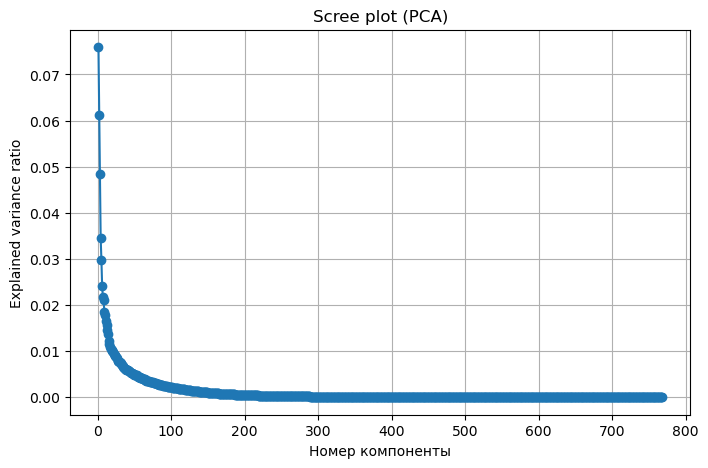

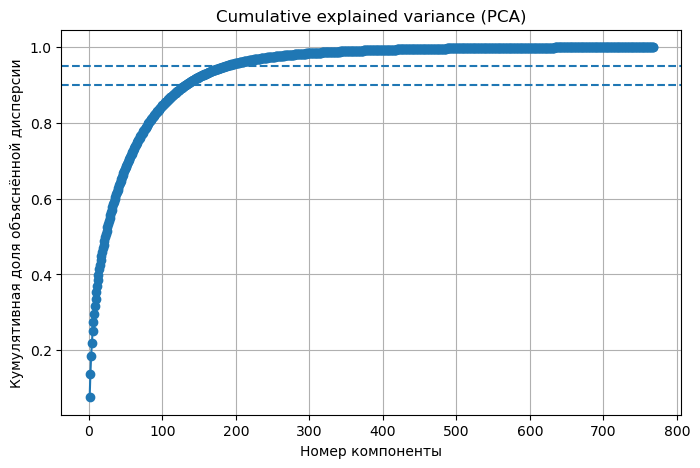

X_pca90 shape: (2000, 132)
X_pca95 shape: (2000, 186)


In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ---- 1) PCA на всех компонентах ( до min(n_samples, n_features) ) ----
X = embeddings  # ваша матрица (N_docs, 768)
pca = PCA(n_components=min(X.shape[0], X.shape[1]), svd_solver="full", random_state=42)
pca.fit(X)

evr = pca.explained_variance_ratio_              # доля дисперсии по компонентам
cum = np.cumsum(evr)                              # кумулятивная доля

# ---- 2) сколько компонент нужно для 90% и 95% дисперсии ----
n90 = int(np.searchsorted(cum, 0.90) + 1)
n95 = int(np.searchsorted(cum, 0.95) + 1)

print(f"Компонент для 90% дисперсии: {n90}")
print(f"Компонент для 95% дисперсии: {n95}")
print(f"Первые 10 EVR: {np.round(evr[:10], 4)}")
print(f"Кумулятивная EVR (первые 10): {np.round(cum[:10], 4)}")

# ---- 3) Графики ----
# Scree plot (EVR)
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(evr)+1), evr, marker='o')
plt.xlabel("Номер компоненты")
plt.ylabel("Explained variance ratio")
plt.title("Scree plot (PCA)")
plt.grid(True)
plt.show()

# Cumulative EVR
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cum)+1), cum, marker='o')
plt.axhline(0.90, linestyle='--')
plt.axhline(0.95, linestyle='--')
plt.xlabel("Номер компоненты")
plt.ylabel("Кумулятивная доля объяснённой дисперсии")
plt.title("Cumulative explained variance (PCA)")
plt.grid(True)
plt.show()

# ---- 4) Сжимаем до найденных размерностей ----
pca90 = PCA(n_components=n90, svd_solver="full", random_state=42).fit(X)
X_pca90 = pca90.transform(X)   # для кластеризации (баланс точности/скорости)

pca95 = PCA(n_components=n95, svd_solver="full", random_state=42).fit(X)
X_pca95 = pca95.transform(X)   # более «бережное» сжатие

print("X_pca90 shape:", X_pca90.shape)
print("X_pca95 shape:", X_pca95.shape)


__7.__ Проведи кластеризацию c помощью `K-means`, количество кластеров попробуйте сделать 5

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import Normalizer
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

X_emb = Normalizer().fit_transform(embeddings)

agg = AgglomerativeClustering(n_clusters=5, linkage="ward")
labels_pred = agg.fit_predict(X_emb)

print("NMI:", normalized_mutual_info_score(df["label"], labels_pred))
print("ARI:", adjusted_rand_score(df["label"], labels_pred))


NMI: 0.3005317041261399
ARI: 0.26763183904540444


In [21]:
# =========================
# GIGA-PIPELINE FOR 5 CLUSTERS
# =========================
# Что делает скрипт:
# 1) Берёт тексты из df_clean (предпочтение: content_lemmas -> content_no_stopwords -> content_clean).
# 2) Строит эмбеддинги на GPU (если доступен) через SentenceTransformer.
# 3) Готовит разные фичпространства:
#    - EMB  : L2-нормированные эмбеддинги
#    - PCA90: PCA до 90% дисперсии
#    - PCA95: PCA до 95% дисперсии
#    - UMAP50 (опц.): UMAP до 50 признаков (метрика cosine)
# 4) Гоняет кластеризацию с k=5: KMeans(n_init=50) и Agglomerative (linkage='ward' для евклида).
# 5) Метрики: Silhouette (на L2-нормированных фичах ~ косинус), NMI, ARI. Собирает и сортирует таблицу.

import os, time, math, warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import (
    silhouette_score,
    normalized_mutual_info_score,
    adjusted_rand_score,
    rand_score,
    homogeneity_score,
    completeness_score,
    v_measure_score
)
import numpy as np
import pandas as pd

# ===== 0) ДАННЫЕ =====
# Предполагаем, что у тебя уже есть:
# - df_clean (с колонками content_lemmas / content_no_stopwords / content_clean)
# - df (исходный датасет с df["label"])
assert 'df' in globals(), "Ожидаю исходный df с колонкой 'label'"
assert 'df_clean' in globals(), "Ожидаю df_clean с очищенными текстами"

# Тексты: леммы -> без стоп-слов -> базовая очистка
if "content_lemmas" in df_clean.columns:
    texts_series = df_clean["content_lemmas"].fillna("")
elif "content_no_stopwords" in df_clean.columns:
    texts_series = df_clean["content_no_stopwords"].fillna("")
else:
    texts_series = df_clean["content_clean"].fillna("")

texts = texts_series.tolist()
true_labels = df["label"].values
k_true = len(pd.Series(true_labels).unique())

print(f"[info] Документов: {len(texts)} | Классов в label: {k_true}")

# ===== 1) ЭМБЕДДИНГИ НА GPU =====
import torch
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[info] Torch CUDA available: {torch.cuda.is_available()} | device = {device}")

# Пара моделей на выбор: мультиязычная (надёжная) и лёгкая русская.
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
# альтернативы (на случай экспериментов):
# MODEL_NAME = "ai-forever/sbert_large_nlu_ru"  # тяжёлая русская
# MODEL_NAME = "cointegrated/rubert-tiny2"     # лёгкая русская, но тогда нужно manual pooling через transformers

t0 = time.time()
model = SentenceTransformer(MODEL_NAME, device=device)
if device == "cuda":
    # half-precision для ускорения/экономии памяти на Ampere (RTX 30xx)
    try:
        model = model.half()
        print("[info] model.half() enabled")
    except Exception as e:
        print("[warn] half precision not set:", e)

embeddings = model.encode(
    texts,
    batch_size=64,               # можно 64-128 на 8 ГБ VRAM
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True    # L2-нормализация: хорошо для косинуса и KMeans/аггломеративной
)
t1 = time.time()
print(f"[info] Embeddings shape: {embeddings.shape} | time: {t1 - t0:.1f}s")

# ===== 2) ПОДГОТОВКА ПРОСТРАНСТВ =====
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer

# Базовые эмбеддинги (уже L2-нормированы)
X_EMB = embeddings

# PCA до 90% / 95% дисперсии
def pca_keep_variance(X, target=0.95, random_state=42):
    p = PCA(n_components=min(X.shape), svd_solver="full", random_state=random_state)
    p.fit(X)
    cum = np.cumsum(p.explained_variance_ratio_)
    n = int(np.searchsorted(cum, target) + 1)
    p = PCA(n_components=n, svd_solver="full", random_state=random_state).fit(X)
    return p.transform(X), n

X_PCA90, n90 = pca_keep_variance(X_EMB, 0.90)
X_PCA95, n95 = pca_keep_variance(X_EMB, 0.95)
# нормализуем снова (после PCA длины векторов меняются)
X_PCA90 = Normalizer().fit_transform(X_PCA90)
X_PCA95 = Normalizer().fit_transform(X_PCA95)

print(f"[info] PCA90 -> shape {X_PCA90.shape} (n={n90}), PCA95 -> shape {X_PCA95.shape} (n={n95})")

# UMAP (опционально) — часто даёт +кластера; метрика cosine
# если нет umap-learn, поставь: pip install umap-learn
try:
    import umap
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.05, n_components=50, metric="cosine", random_state=42)
    X_UMAP50 = reducer.fit_transform(X_EMB)  # на 2000*768 быстро
    X_UMAP50 = Normalizer().fit_transform(X_UMAP50)
    has_umap = True
    print(f"[info] UMAP50 -> shape {X_UMAP50.shape}")
except Exception as e:
    has_umap = False
    print("[warn] UMAP недоступен, пропускаю (pip install umap-learn). Ошибка:", e)

# ===== 3) КЛАСТЕРИЗАТОРЫ =====
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, normalized_mutual_info_score, adjusted_rand_score

def eval_clustering(X, y_true, algo_name, labels_pred):
    # Silhouette
    try:
        sil = silhouette_score(X, labels_pred)
    except Exception:
        sil = np.nan
    # Метрики с метками
    nmi = normalized_mutual_info_score(y_true, labels_pred)
    ari = adjusted_rand_score(y_true, labels_pred)
    ri  = rand_score(y_true, labels_pred)  # без поправки
    hom = homogeneity_score(y_true, labels_pred)
    com = completeness_score(y_true, labels_pred)
    vms = v_measure_score(y_true, labels_pred)
    return dict(
        algo=algo_name,
        silhouette=sil,
        nmi=nmi,
        ari=ari,
        rand=ri,
        homogeneity=hom,
        completeness=com,
        v_measure=vms
    )

results = []

def run_all_for_space(X, space_name, k=5):
    # KMeans
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    y_km = km.fit_predict(X)
    results.append(eval_clustering(X, true_labels, f"{space_name} + KMeans(k={k})", y_km))

    # Agglomerative (евклид, linkage='ward' требует евклид и dense)
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    y_ag = agg.fit_predict(X)
    results.append(eval_clustering(X, true_labels, f"{space_name} + Agglomerative(k={k}, ward)", y_ag))

# Гоняем все пространства
run_all_for_space(X_EMB,   "EMB",  k=5)
run_all_for_space(X_PCA90, "PCA90",k=5)
run_all_for_space(X_PCA95, "PCA95",k=5)
if has_umap:
    run_all_for_space(X_UMAP50, "UMAP50", k=5)

# ===== 4) СВОДКА =====
res_df = pd.DataFrame(results).sort_values(["nmi","ari","silhouette"], ascending=False)
print("\n=== Результаты (лучшее сверху) ===")
print(res_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

best = res_df.iloc[0]
print(f"\n[best] {best['algo']} | NMI={best['nmi']:.3f} | ARI={best['ari']:.3f} | Sil={best['silhouette']:.3f}")

# ===== 5) ФИНАЛЬНЫЕ МЕТКИ ЛУЧШЕГО ПАЙПЛАЙНА (пример для применения) =====
# Хочешь — добавлю сохранение меток лучшего варианта в df_clean["cluster_best"]
ALG = best['algo']
def get_labels_for_algo(algo_name):
    if algo_name.startswith("EMB"):
        X = X_EMB
    elif algo_name.startswith("PCA90"):
        X = X_PCA90
    elif algo_name.startswith("PCA95"):
        X = X_PCA95
    elif algo_name.startswith("UMAP50"):
        X = X_UMAP50
    else:
        raise ValueError("Unknown space")
    if "KMeans" in algo_name:
        km = KMeans(n_clusters=5, random_state=42, n_init=50)
        return km.fit_predict(X)
    else:
        agg = AgglomerativeClustering(n_clusters=5, linkage="ward")
        return agg.fit_predict(X)

assert "label" in df.columns, "В исходном df нет колонки 'label'"
df_clean["label"] = df["label"].values

df_clean["cluster_best"] = get_labels_for_algo(ALG)
df_clean[["content", "label", "cluster_best"]].head(10)


[info] Документов: 2000 | Классов в label: 5
[info] Torch CUDA available: True | device = cuda
[info] model.half() enabled


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

[info] Embeddings shape: (2000, 768) | time: 6.9s
[info] PCA90 -> shape (2000, 132) (n=132), PCA95 -> shape (2000, 186) (n=186)
[info] UMAP50 -> shape (2000, 50)

=== Результаты (лучшее сверху) ===
                             algo  silhouette   nmi   ari  rand  homogeneity  completeness  v_measure
UMAP50 + Agglomerative(k=5, ward)       0.362 0.419 0.372 0.772        0.397         0.444      0.419
             UMAP50 + KMeans(k=5)       0.382 0.344 0.304 0.760        0.340         0.349      0.344
 PCA95 + Agglomerative(k=5, ward)       0.039 0.341 0.286 0.755        0.336         0.346      0.341
              PCA90 + KMeans(k=5)       0.064 0.316 0.286 0.762        0.315         0.316      0.316
              PCA95 + KMeans(k=5)       0.061 0.315 0.286 0.761        0.315         0.316      0.315
 PCA90 + Agglomerative(k=5, ward)       0.032 0.305 0.277 0.747        0.298         0.313      0.305
                EMB + KMeans(k=5)       0.045 0.302 0.265 0.755        0.302         0.3

,content,label,cluster_best
0,Мужчину в метро оскорбила сумка с репродукцией...,искусство,0
1,В одном из кинотеатров Нидерландов перед просм...,маркетинг,0
2,🖼️ «Христос в Галилейском море» — Эжен Делакру...,искусство,0
3,"24 года Яндекс работает, чтобы делать жизнь уд...",технологии,1
4,Телеком 2022 - 2 прибыльных #MVNO и остальные🔥...,технологии,1
5,Нужно ли прижигать эрозию шейки матки?Во-первы...,здоровье_медицина,2
6,10 декабря 1901 года состоялась первая церемон...,здоровье_медицина,3
7,Такими темпами можно вообще весь балет отменить),искусство,0
8,К 80-летию режиссера Маргарете фон Тротта сост...,искусство,0
9,В Дагестане медработники получили отпускные и ...,здоровье_медицина,2


In [ ]:
pd.crosstab(df_clean["cluster_best"], df_clean["label"])


label,здоровье_медицина,искусство,маркетинг,образование_познавательное,технологии
cluster_best,,,,,
0,22,269,185,76,87
1,3,11,169,30,420
2,358,1,6,16,3
3,20,10,25,175,71
4,1,4,0,38,0


__8.__ Выведи топ15 слов для каждого кластера

In [ ]:
# your_code

__9.__ Посчитай внутренние(`silhouette_score`) и внешние метрики(`rand_score`). Для внешник метрик у вас есть разметка в исходных данных в столбце `label`

In [ ]:
#your_code

__10.__ Попробуйте построить `wordcloud` - ссылка на [туториал](https://www.datacamp.com/tutorial/wordcloud-python)

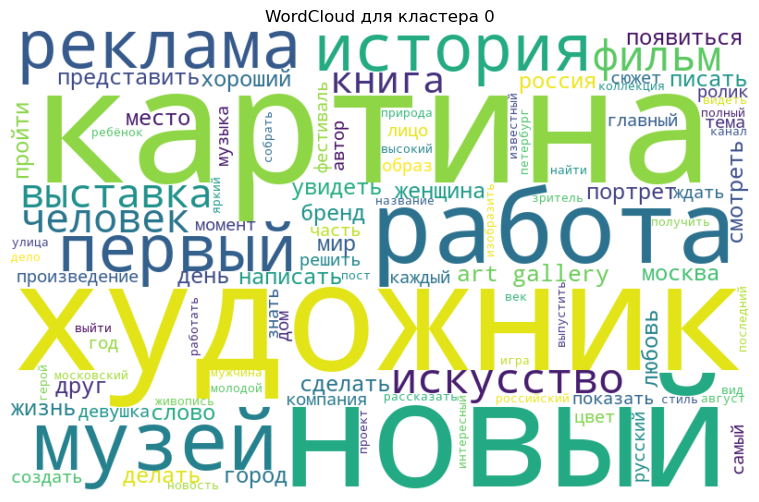

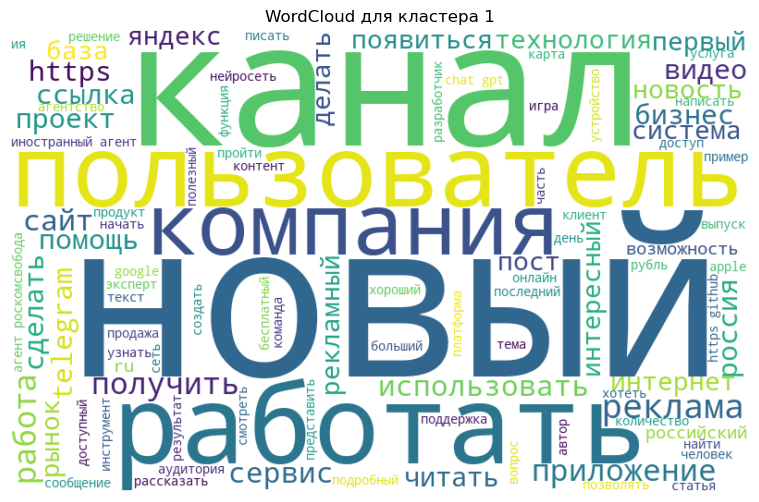

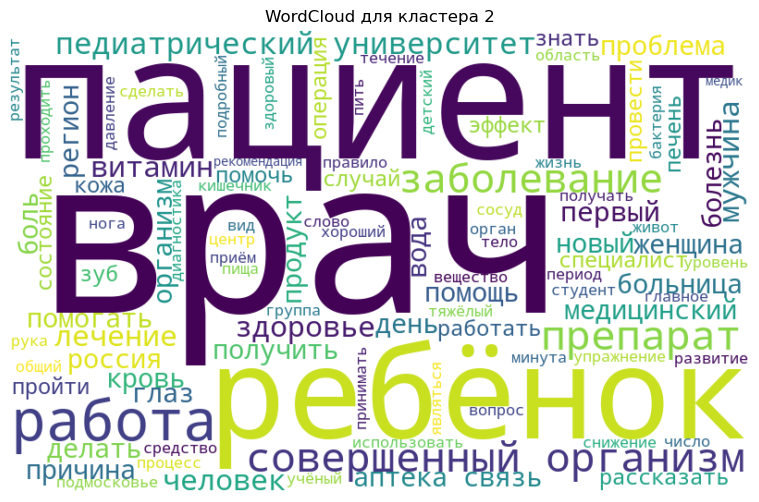

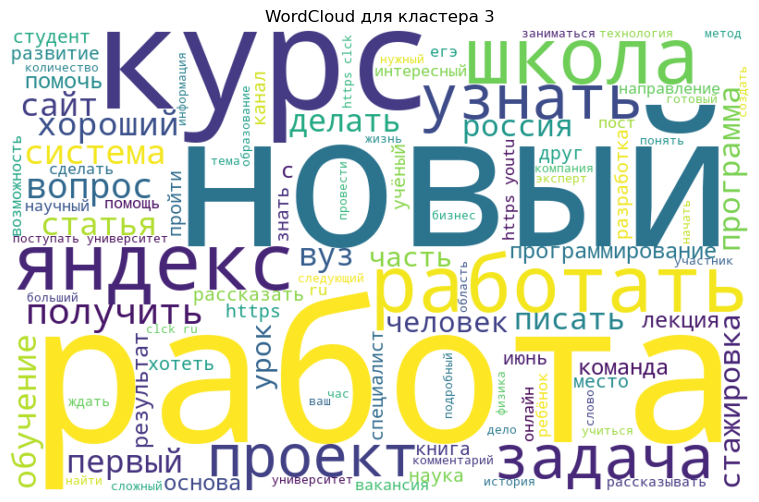

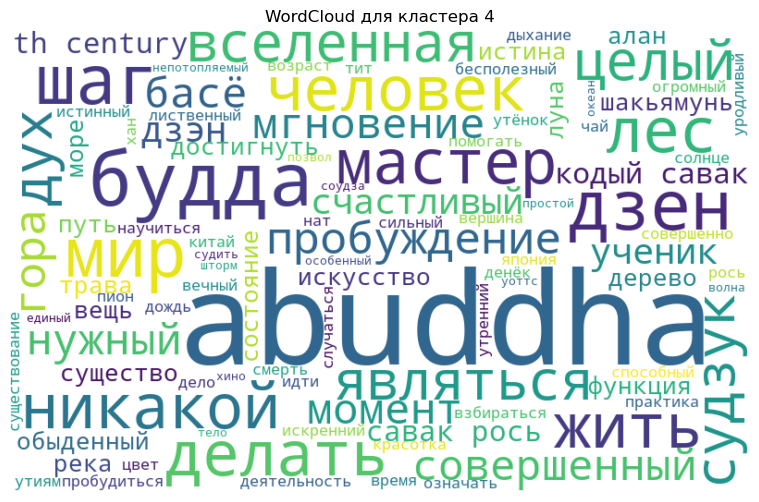

In [ ]:

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# выберем колонку с кластерами
cluster_col = "cluster_best"   # если у тебя она так называется
texts_by_cluster = df_clean.groupby(cluster_col)["content_lemmas"].apply(lambda x: " ".join(x))

# рисуем облако слов для каждого кластера
for cluster_id, text in texts_by_cluster.items():
    if not text.strip():
        continue
    wc = WordCloud(width=800, height=500, background_color="white", colormap="viridis",
                   max_words=100, font_path=None)  # font_path можно указать, если кириллица не отображается
    wc.generate(text)
    
    plt.figure(figsize=(10,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud для кластера {cluster_id}")
    plt.show()


In [22]:
# === 2D/3D визуализация лучших кластеров на Plotly ===
# Предполагаем, что у тебя уже есть:
# - embeddings  : np.ndarray (N, 768) из Sentence-BERT
# - df_clean    : DataFrame с колонками: content / label / cluster_best  (лучший алгоритм)
# - X_UMAP50    : np.ndarray (N, 50)     (если нет — не страшно)
# Если чего-то нет — этот код аккуратно досчитает нужное.

import numpy as np
import pandas as pd
import plotly.express as px

# 1) убеждаемся, что есть метки лучшего кластера
assert "cluster_best" in df_clean.columns, "В df_clean нет колонки 'cluster_best'. Запусти ваш giga-пайплайн, чтобы её создать."

# 2) 2D/3D UMAP-проекции
try:
    import umap
except ImportError as e:
    raise RuntimeError("Нужен пакет umap-learn: pip install umap-learn") from e

# базовое пространство для проекций — лучше из исходных эмбеддингов
X_base = embeddings

# UMAP-2D
umap2d = umap.UMAP(n_neighbors=15, min_dist=0.05, n_components=2, metric="cosine", random_state=42)
X_2d = umap2d.fit_transform(X_base)  # (N, 2)

# UMAP-3D
umap3d = umap.UMAP(n_neighbors=15, min_dist=0.05, n_components=3, metric="cosine", random_state=42)
X_3d = umap3d.fit_transform(X_base)  # (N, 3)

# 3) Подготовим датафреймы для плотли
def truncate(s, n=140):
    s = str(s)
    return s if len(s) <= n else s[:n-1] + "…"

df_plot2d = pd.DataFrame({
    "x": X_2d[:, 0],
    "y": X_2d[:, 1],
    "cluster": df_clean["cluster_best"].astype(str),
    "label": df_clean["label"].astype(str),
    "text": df_clean["content"].apply(lambda t: truncate(t, 160))
})

df_plot3d = pd.DataFrame({
    "x": X_3d[:, 0],
    "y": X_3d[:, 1],
    "z": X_3d[:, 2],
    "cluster": df_clean["cluster_best"].astype(str),
    "label": df_clean["label"].astype(str),
    "text": df_clean["content"].apply(lambda t: truncate(t, 160))
})

# 4) Plotly 2D
fig2d = px.scatter(
    df_plot2d, x="x", y="y",
    color="cluster",  # раскраска по предсказанным кластерам
    symbol="label",   # форма маркера по истинным меткам (удобно для сравнения)
    hover_data={"text": True, "cluster": True, "label": True, "x": False, "y": False},
    title="UMAP 2D — лучшая связка (цвет=кластер, символ=истинный label)"
)
fig2d.update_traces(marker=dict(size=6, opacity=0.85))
fig2d.show()

# 5) Plotly 3D
fig3d = px.scatter_3d(
    df_plot3d, x="x", y="y", z="z",
    color="cluster",
    symbol="label",
    hover_data={"text": True, "cluster": True, "label": True, "x": False, "y": False, "z": False},
    title="UMAP 3D — лучшая связка (цвет=кластер, символ=истинный label)"
)
fig3d.update_traces(marker=dict(size=3, opacity=0.85))
fig3d.update_layout(scene=dict(xaxis_title="UMAP-1", yaxis_title="UMAP-2", zaxis_title="UMAP-3"))
fig3d.show()


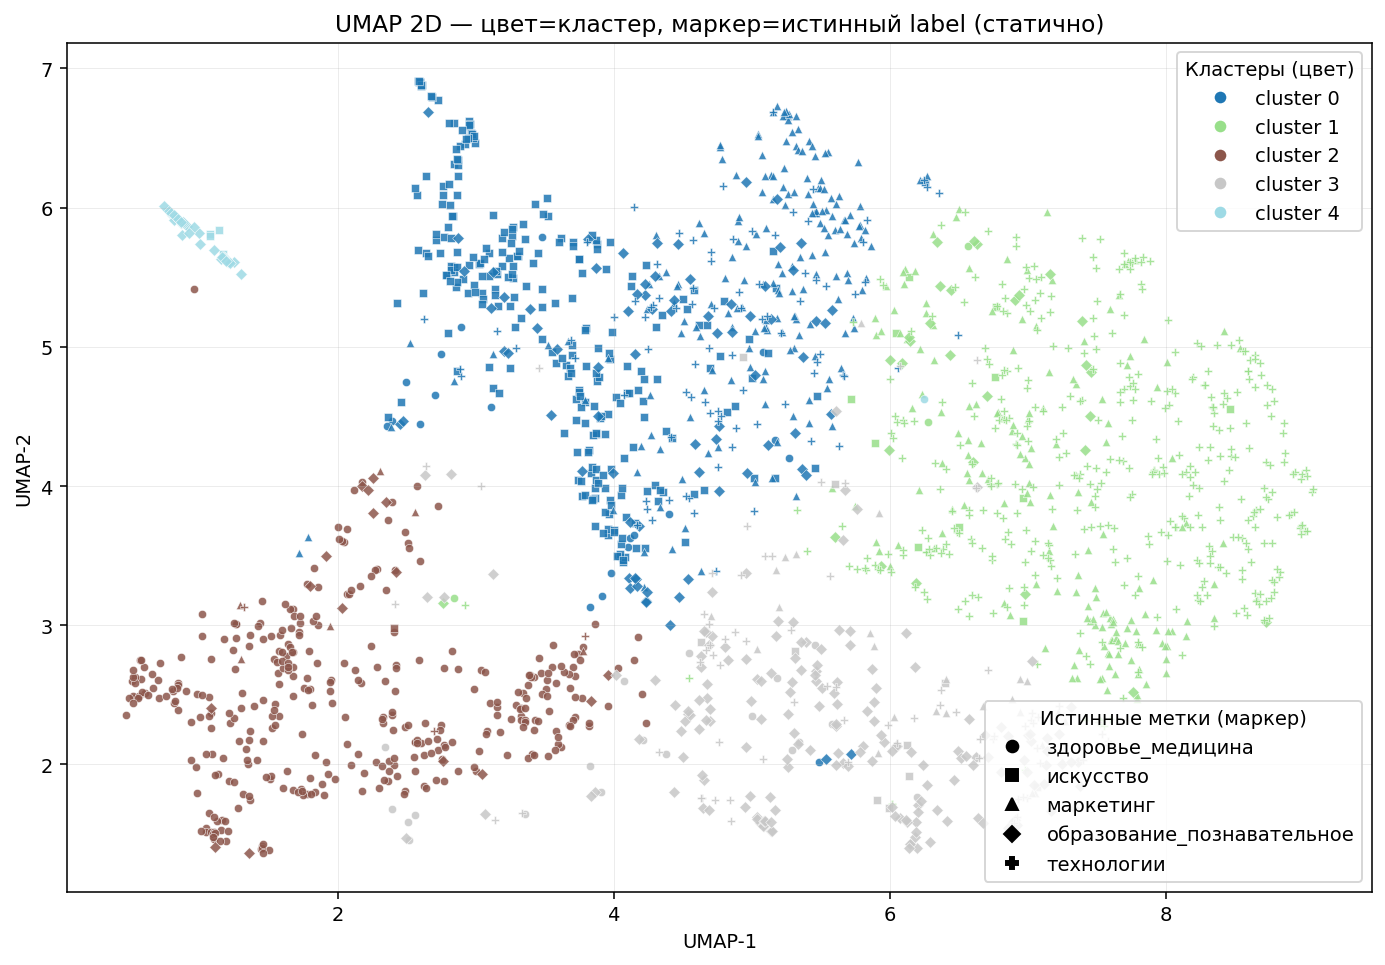

In [23]:
# === 2D (matplotlib, статично) + 3D (plotly) для лучшей связки ===
# Требуется:
# - embeddings : np.ndarray (N, 768)
# - df_clean   : DataFrame с колонками ["content", "label", "cluster_best"]
# Если X_2d/X_3d ещё нет, посчитаем UMAP из embeddings.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 0) sanity-check
assert "cluster_best" in df_clean.columns, "Нет df_clean['cluster_best'] — запусти кластеризацию."
assert "label" in df_clean.columns, "Нет df_clean['label'] — протяни метки из исходного df."
N = len(df_clean)

# 1) UMAP-проекции (если ещё не считали)
try:
    X_2d
except NameError:
    import umap
    umap2d = umap.UMAP(n_neighbors=15, min_dist=0.05, n_components=2, metric="cosine", random_state=42)
    X_2d = umap2d.fit_transform(embeddings)  # (N, 2)

try:
    X_3d
except NameError:
    import umap
    umap3d = umap.UMAP(n_neighbors=15, min_dist=0.05, n_components=3, metric="cosine", random_state=42)
    X_3d = umap3d.fit_transform(embeddings)  # (N, 3)

# 2) Подготовка данных и стилей для 2D (без динамических подсказок)
clusters = df_clean["cluster_best"].astype(str).values
labels   = df_clean["label"].astype(str).values
texts    = df_clean["content"].astype(str).values

# Маркеры по истинным меткам (до 10 разных, при большем количестве — повторяются)
MARKERS = ["o","s","^","D","P","X","v","<",">","*"]
unique_labels   = sorted(pd.unique(labels))
label_to_marker = {lab: MARKERS[i % len(MARKERS)] for i, lab in enumerate(unique_labels)}

# Цвета по кластерам (используем colormap для воспроизводимости)
unique_clusters = sorted(pd.unique(clusters))
cmap = plt.cm.get_cmap("tab20", len(unique_clusters))
cluster_to_color = {cl: cmap(i) for i, cl in enumerate(unique_clusters)}

# 3) Рисуем статичный 2D scatter: цвет = кластер, маркер = label
fig, ax = plt.subplots(figsize=(10, 7), dpi=140)

for cl in unique_clusters:
    mask_cl = (clusters == cl)
    # внутри кластера разбиваем по label, чтобы разные маркеры попали в легенду
    for lab in unique_labels:
        mask = mask_cl & (labels == lab)
        if not mask.any():
            continue
        ax.scatter(
            X_2d[mask, 0],
            X_2d[mask, 1],
            s=18, linewidths=0.3, edgecolors="white",
            marker=label_to_marker[lab],
            c=[cluster_to_color[cl]],
            alpha=0.85,
            label=f"cluster {cl} | label {lab}"
        )

# Две отдельные легенды: по кластерам (цвета) и по labels (маркеры)
# Легенда по кластерам (цвет)
from matplotlib.lines import Line2D
cluster_handles = [Line2D([0],[0], marker="o", color="w", label=f"cluster {cl}",
                          markerfacecolor=cluster_to_color[cl], markersize=7) for cl in unique_clusters]
legend1 = ax.legend(handles=cluster_handles, title="Кластеры (цвет)", loc="upper right", frameon=True)
ax.add_artist(legend1)

# Легенда по меткам (маркер)
label_handles = [Line2D([0],[0], marker=label_to_marker[lab], color="k", linestyle="",
                        label=str(lab), markersize=6) for lab in unique_labels]
ax.legend(handles=label_handles, title="Истинные метки (маркер)", loc="lower right", frameon=True)

ax.set_title("UMAP 2D — цвет=кластер, маркер=истинный label (статично)")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.grid(True, linewidth=0.3, alpha=0.4)

plt.tight_layout()
plt.show()

# 4) 3D интерактив (Plotly), как было
import plotly.express as px

def truncate(s, n=140):
    s = str(s)
    return s if len(s) <= n else s[:n-1] + "…"

df_plot3d = pd.DataFrame({
    "x": X_3d[:, 0],
    "y": X_3d[:, 1],
    "z": X_3d[:, 2],
    "cluster": df_clean["cluster_best"].astype(str),
    "label": df_clean["label"].astype(str),
    "text": df_clean["content"].apply(lambda t: truncate(t, 160))
})

fig3d = px.scatter_3d(
    df_plot3d, x="x", y="y", z="z",
    color="cluster",
    symbol="label",
    hover_data={"text": True, "cluster": True, "label": True, "x": False, "y": False, "z": False},
    title="UMAP 3D — цвет=кластер, символ=истинный label"
)
fig3d.update_traces(marker=dict(size=3, opacity=0.85))
fig3d.update_layout(scene=dict(xaxis_title="UMAP-1", yaxis_title="UMAP-2", zaxis_title="UMAP-3"))
fig3d.show()


__11.__ Задание со звездочкой. Оберни всю работу выше в итоговый пайплайн следующего вида:  
   * `MyCustomPreprocessorText` __->__ `CountVectorizer` __->__ `TruncatedSVD` __->__ `Kmeans`
   * `MyCustomPreprocessorText` внутри себя будет содержать все этапы предобработки и очистки текста:
        - `clean` __->__ `remove_stopwords` __->__ `lemmitize`
   * Обучи и подай на вход текст "Этот текст о рекламе, о маркетинге и его пользе для любого продукта для людей" и проверь, к какому кластеру отнесется данный объект

__Некоторый шаблон в помощи сборки своего препроцессора указан ниже__

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
import pymorphy3

class MyCustomTextPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.stop_words = self.get_stopwords_list() 
        self.morph = pymorphy3.MorphAnalyzer()

    def fit(self, X, y=None): # Препроцессору обучаться не нужно, его нужно только преобразовывать, поэтому тут пусто
        return self

    def transform(self, texts, y=None): # Будет преобразоваывать
        return [self.preprocess(text) for text in texts]

    # Здесь можно прописать код получения словаря со стоп-словами
    def get_stopwords_list(self): 
        # your_code
        return # stop_words

    # Функция по очистке текста
    def clean(self, text):
        # вставьте сюда свою функцию clean из заданий выше
        return # text

    def remove_stopwords(self, text):
        # Здесь можно вставить свою функцию remove_stopwords написанную в заданиях выше
        return filtered_text
    
    
    def lemmatize(self, text):
        # Вставьте lemmatize
        return lemmatized_text

    # Функция, которая запустит последовательный запуск всех этапов выше
    def preprocess(self, text):
        text = self.clean(text)
        text = self.remove_stopwords(text)
        text = self.lemmatize(text)
        return text

* Проверьте его, работает ли правильно transform у этого класса, если все ок 

In [ ]:
# pipeline = Pipeline([
#     ('preprocessor', MyCustomTextPreprocessor()),
# ])

# pipeline.transform(["Этот текст о рекламе, о маркетинге и его пользе для любого продукта для людей"])

* А теперь соберите полный пайплайн и посчитайте кластер данного текста